In [ ]:
import numpy as np
from pathlib import Path

# ------------ 1.  设置实验数据 ------------
star_points = {
    'frequency': [6.38, 6.2, 6.02, 6.01, 6.0, 5.9, 5.0,
                  4.8, 4.763, 4.762, 4.759, 4.5,
                  3.846, 6.666, 8.25],                # kHz
    'heating':   [287.393788264347, 193.616801258866, 165.112956629879,
                  42.126115596758,  49.393907101534,  371.762594973729,
                  455.879839044447, 378.844180607177, 45.611693284959,
                  36.838562612508,  74.572478160620,  191.305603411685,
                  384.763981809354, 736.695071670842, 770.682554687554]
}

star_points = {
    'frequency': [6.38, 6.2, 6.02, 6.01, 6.0, 5.9, 5.0, 4.763, 4.762, 4.759, 4.5,
                  3.846, 6.666, 8.25],                # kHz
    'heating':   [287.393788264347, 193.616801258866, 165.112956629879,
                  42.126115596758,  49.393907101534,  371.762594973729,
                  378.844180607177, 45.611693284959,
                  36.838562612508,  74.572478160620,  191.305603411685,
                  384.763981809354, 736.695071670842, 770.682554687554]
}

star_points = {
    'frequency': [
        8.25, 6.666, 6.566, 6.493, 6.493, 6.451, 6.421, 6.42, 6.417, 6.416,
        6.415, 6.414, 6.413, 6.41, 6.4, 6.39, 6.38, 6.35, 6.2, 6.1,
        6.05, 6.02, 6.01, 6.005, 6.0, 6.0, 6.0, 6.0, 5.99, 5.98,
        5.98, 5.9, 5.882, 5.7, 5.556, 5.5, 5.3, 5.263, 5.2, 5.15,
        5.1, 5.0, 5.0, 5.0, 4.8, 4.763, 4.762, 4.762, 4.761, 4.761,
        4.761, 4.76, 4.759, 4.5454, 4.5, 4.3478, 4.0, 3.846
    ],
    'heating': [
        281.58589623054934, 200.7324234189531, 214.29160081791673, 200.2473666184795, 185.14538866024353,
        33.73375833557035, 195.53577775161128, 84.05859629327496, 198.09122910733922, 195.02937870168935,
        46.79215727156546, 200.252227028215, 192.19730214625747, 198.9614233697037, 86.19494518486586, 
        116.32823174067242, 212.61003978961034, 193.26207880007158, 193.86020664113673, 201.14712031963944,
        194.48764585107918, 187.85689346484259, 81.33247724126869, 44.95105982249805, 199.66716121959172,
        52.92266545024485, 155.45171953033557, 172.57851055503238, 80.5274459513275, 28.14945750799304,
        42.220512963138916, 278.5892442897424, 288.8740695272039, 123.25832882842471, 214.9509085248041,
        206.5488975920686, 193.05650183895202, 225.5658887157739, 44.376284050900004, 174.86382760471616,
        198.87628823340864, 216.1156648980022, 208.18389405221404, 212.65885620077262, 193.41364979028953,
        45.420919288688886, 134.24366393701607, 25.92863750048396, 97.58090149053932, 13.280270708153308,
        44.528310818993205, 58.33065324507537, 92.3050347757307, 211.42900830739495, 55.51447471638855,
        173.03625935992437, 81.17309805846864, 174.39442187922089
    ]
}

# ------------ 2.  计算时间并统一缩放 ------------
scale_factor      = 86 / 135.5087462284        # ≈ 0.63494002
conversion_factor = 275/2                      # μs  (8.25 kHz → 137.5 μs)

star_points['time'] = [(8.25/f)*conversion_factor*scale_factor
                       for f in star_points['frequency']]

exp_points = np.column_stack((star_points['time'], star_points['heating']))
out_dir = Path('./outputs'); out_dir.mkdir(exist_ok=True)
experimental_points_path = out_dir / 'experimental_points.npy'
np.save(experimental_points_path, exp_points)

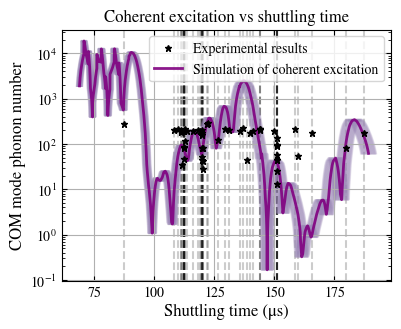

In [4]:
import numpy as np
import matplotlib
from pathlib import Path
import matplotlib.pyplot as plt

matplotlib.rcParams.update(
        {"font.family": "STIXGeneral",
         "xtick.labelsize": 12,
         "xtick.direction": "in",
         "xtick.major.pad": 3,
         "xtick.top": True,
         "ytick.labelsize": 12,
         "ytick.direction": "in",
         "ytick.right": True,
         "axes.labelsize": 12,
         "axes.labelpad": 3,
         "axes.grid": True
    }
)

out_dir = Path("./outputs")

t_avg = np.load(out_dir / "avg_curve_time.npy")        # shape (N,)
p_avg = np.load(out_dir / "avg_curve_phonon.npy")      # shape (N,)
exp_points = np.load(out_dir / "experimental_points.npy")

half_column_width_inches = 4.25
aspect_ratio = 1.3

# ------------------------------------------------------------------
# 1. Build many scaled-time curves (20 samples across ±3 σ)
scale_delta = 3.03 / 179.96
n_samples = 50
scales = np.linspace(1 - scale_delta, 1 + scale_delta, n_samples)

# t_scaled has shape (n_samples, N)
t_scaled = scales[:, None] * t_avg[None, :]

# 2. Envelope in time for every phonon value
t_min = t_scaled.min(axis=0)
t_max = t_scaled.max(axis=0)

# 3. Sort by phonon number so fill_betweenx doesn’t self-intersect
order = np.argsort(p_avg)
p_sorted   = p_avg[order]
t_min_sort = t_min[order]
t_max_sort = t_max[order]

# ------------------------------------------------------------------
plt.figure(figsize=(half_column_width_inches,
                    half_column_width_inches / aspect_ratio))

# # Shade the full envelope
# plt.fill_betweenx(p_sorted, t_min_sort, t_max_sort,
#                   color="#9c89b8", alpha=0.45,
#                   label="Trap frequency ±3σ", zorder=1)

# (Optional) show the individual realisations very faintly
for ts in t_scaled:
    plt.plot(ts, p_avg, color="#9c89b8", alpha=0.15, zorder=1)

# Experimental points
plt.plot(exp_points[:, 0], exp_points[:, 1], "k*", markersize=5,
         label="Experimental results", zorder=3)

# Central (mean) curve
plt.plot(t_avg, p_avg, "-", lw=2, color="purple", alpha=0.9,
         label="Simulation of coherent excitation", zorder=2)

# Vertical guide lines at experimental times (optional)
for tx in exp_points[:, 0]:
    plt.axvline(tx, color="black", linestyle="--", alpha=0.2, zorder=0)

plt.xlabel("Shuttling time (μs)", fontsize=12)
plt.ylabel("COM mode phonon number", fontsize=12)
plt.title("Coherent excitation vs shuttling time", fontsize=12)
plt.yscale("log")
plt.grid(True)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend()

plt.savefig(out_dir / "Phonon_number_vs_shuttling_time_from_cache.pdf",
            format="pdf", bbox_inches="tight")
plt.show()


Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters:
rabi =  0.100373328165327
nbar =  8.685782841519803
nalpha =  14.805842118731894
A =  0.9881694444039764


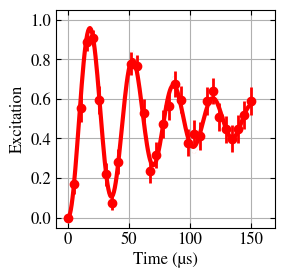

In [26]:
from qutip import *
from scipy.optimize import curve_fit
import math
import cmath
import timeit
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from time import time
from pynverse import inversefunc
from mpl_toolkits.axisartist.axislines import SubplotZero
import matplotlib
import h5py as h5
from scipy.special import eval_laguerre
from scipy.integrate import dblquad, quad
import scipy

# Update matplotlib settings for consistent appearance in plots
matplotlib.rcParams.update(
    {
        "font.family": "STIXGeneral",
        "xtick.labelsize": 12,
        "xtick.direction": "in",
        "xtick.major.pad": 3,
        "xtick.top": True,
        "ytick.labelsize": 12,
        "ytick.direction": "in",
        "ytick.right": True,
        "axes.labelsize": 12,
        "axes.labelpad": 3,
        "axes.grid": True,
    }
)

# File loading function
def file_loading(
    data_path,
    date,
    index,
    number,
    x="rabi_t",
    y="pmt_counts_avg_thresholded",
    exp="RabiTimeScan",
):
    file_path = data_path + date + index + f"/0000{number}-" + exp + ".h5"

    with h5.File(file_path, "r") as file:
        datasets_keys = list(file["datasets"].keys())
        print("Datasets available:", datasets_keys)
        x_data = file["datasets"][x][:]
        y_data = file["datasets"][y][:]

    return x_data, y_data, np.linspace(np.min(x_data), np.max(x_data), 300)


###########################################
# Load and preprocess the data
###########################################

n_samples = 50

# Specify the data path and file details
data_path = "/Users/bingran_you/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30462

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = [9]
keep_indices = np.ones(len(rabi_t), dtype=bool)
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (
    (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples))
    / np.max(pmt_counts_avg_thresholded)
)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

###########################################
# Define the model and fit parameters
###########################################

n_ions = 9
N = 300

INTENSITY_DISTRIBUTION = np.array(
    [0.96912696, 0.9844114, 0.99344862, 0.99840835, 1.0, 0.99840835, 0.99344862, 0.9844114, 0.96912696],
    dtype=float,
)
INTENSITY_WEIGHTS = np.array([2.0, 2.0, 2.0, 2.0, 1.0], dtype=float)  # Legacy weighting
USED_INTENSITIES = INTENSITY_DISTRIBUTION[: INTENSITY_WEIGHTS.size]

ETA = 0.23 / np.sqrt(n_ions)
ETA_SQ = ETA ** 2

_LAGUERRE_CACHE = {}


def _laguerre_values(N):
    if N not in _LAGUERRE_CACHE:
        _LAGUERRE_CACHE[N] = eval_laguerre(np.arange(N), ETA_SQ)
    return _LAGUERRE_CACHE[N]


def _displaced_thermal_diagonal(N, nbar_fit, nalpha_fit):
    ndisplace_fit = 1j * np.sqrt(nalpha_fit)
    displaced = displace(N, ndisplace_fit)
    rho_th = thermal_dm(N, nbar_fit)
    diag = (displaced * rho_th * displaced.dag()).diag()
    diag = np.abs(np.asarray(diag))
    return diag.astype(float)


def _pe_model_core(time, rabi_0_fit, nbar_fit, nalpha_fit, N, return_diag):
    time = np.asarray(time, dtype=float)
    diag = _displaced_thermal_diagonal(N, nbar_fit, nalpha_fit)
    laguerre_vals = _laguerre_values(N)
    prefactor = (rabi_0_fit * laguerre_vals)[:, None] * time[None, :]

    pe_fit = np.zeros(time.size, dtype=float)
    diag_accum = np.zeros_like(diag) if return_diag else None

    for weight, intensity in zip(INTENSITY_WEIGHTS, USED_INTENSITIES):
        sin_term = np.sin(intensity * prefactor) ** 2
        pe_fit += weight * np.sum(diag[:, None] * sin_term, axis=0)
        if return_diag:
            diag_accum += weight * diag

    pe_fit /= n_ions
    if return_diag:
        diag_accum /= n_ions
        return pe_fit, diag_accum
    return pe_fit


def pe_model_optimized(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N):
    return _pe_model_core(time, rabi_0_fit, nbar_fit, nalpha_fit, N, return_diag=True)


def pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N):
    return _pe_model_core(time, rabi_0_fit, nbar_fit, nalpha_fit, N, return_diag=False)


def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit, A_fit, N=N):
    return A_fit * pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N)


bounds = ((0.05, 0, 0, 0.5), (0.15, 10, 300, 1.5))
initial_guess = [(low + high) / 2 for low, high in zip(bounds[0], bounds[1])]

popt, pcov = curve_fit(
    fit_model,
    rabi_t,
    pmt_counts_avg_thresholded,
    p0=initial_guess,
    bounds=bounds,
)
fitted_rabi, fitted_nbar, fitted_nalpha, fitted_amplitude = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)
print("A = ", fitted_amplitude)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
n_ions = 9
N = 300
nalpha = fitted_nalpha
amplitude = fitted_amplitude

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha)
    results.append(amplitude * D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight') 
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999990937463 ± 5.06792922337865
nbar =  0.7334366552021186 ± 79.13146908738052
nalpha =  212.61003978961034 ± 1078.5320286054084
A =  1.1587735029059223 ± 0.07023017666670706


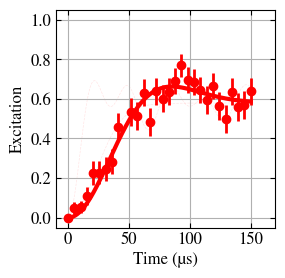

rabi =  0.14999999990937463 ± 5.06792922337865 
nbar =  0.7334366552021186 ± 79.13146908738052 
nalpha =  212.61003978961034 ± 1078.5320286054084 
A =  1.1587735029059223 ± 0.07023017666670706


In [27]:
def heating_rate_processing(data_path, date, index, number, bounds = ((0.02, 0, 1, 0.5), (0.15, 23, 500, 1.5))):
    n_samples = 50

    rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
    rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
    pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

    # Remove unwanted indices if needed
    indices_to_remove = [9]  # Added 12 to the list
    keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
    keep_indices[indices_to_remove] = False
    rabi_t = rabi_t[keep_indices]
    pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

    # Data re-scaling
    errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
    pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
    pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.3

    # Initial guesses
    # initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
    # bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
    # bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
    # Initial guess is the center of the bounds
    initial_guess = [(low + high) / 2 for low, high in zip(bounds[0], bounds[1])]

    # Perform the curve fitting
    popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
    fitted_rabi, fitted_nbar, fitted_nalpha, fitted_amplitude = popt

    with np.errstate(invalid='ignore'):
        perr = np.sqrt(np.diag(pcov))
    perr = np.where(np.isfinite(perr), perr, np.nan)
    fitted_rabi_err, fitted_nbar_err, fitted_nalpha_err, fitted_amplitude_err = perr

    print("Fitted parameters (±1σ):")
    print("rabi = ", fitted_rabi, "±", fitted_rabi_err)
    print("nbar = ", fitted_nbar, "±", fitted_nbar_err)
    print("nalpha = ", fitted_nalpha, "±", fitted_nalpha_err)
    print("A = ", fitted_amplitude, "±", fitted_amplitude_err)

    # Running simulation
    # rabi =  fitted_rabi
    rabi = fitted_rabi
    nbar =  fitted_nbar
    # n_ions = 9
    # N = 400
    nalpha = fitted_nalpha
    amplitude = fitted_amplitude

    # You already have these lines in your code
    time = np.linspace(np.min(times), np.max(times), 200)

    # Running simulation for different nalpha values
    nbars = [nbar - 3, nbar, nbar + 3]
    results = []

    for nbar in nbars:
        D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=500)
        results.append(amplitude * D_population)

    # Create outputs directory if it doesn't exist
    os.makedirs("./outputs/shuttling/", exist_ok=True)

    np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
    np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
    np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
    np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

    rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
    pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
    time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
    results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

    # Plotting
    plt.figure(figsize=(2.83, 2.83))
    errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
    plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
    # plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
    # plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
    plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\bar{{n}}_{{th}} = {np.average(nbars):.1f} \pm {(np.average(nbars) - nbars[0]):.1f}$')
    plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
    plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
    # plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
    # plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
    plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
    plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
    plt.ylim(-0.05, 1.05)
    plt.xlim(-10, 170)
    # plt.legend(loc='lower right')
    # plt.legend()
    plt.grid(True)
    plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
    plt.show()

    return (
        fitted_rabi,
        fitted_nbar,
        fitted_nalpha,
        fitted_amplitude,
        fitted_rabi_err,
        fitted_nbar_err,
        fitted_nalpha_err,
        fitted_amplitude_err,
    )

# Specify the data path and file details
data_path = "/Users/bingran_you/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30516
(
    rabi,
    nbar,
    nalpha,
    amplitude,
    rabi_err,
    nbar_err,
    nalpha_err,
    amplitude_err,
) = heating_rate_processing(data_path, date, index, number)
print("rabi = ", rabi, "±", rabi_err, "\nnbar = ", nbar, "±", nbar_err, "\nnalpha = ", nalpha, "±", nalpha_err, "\nA = ", amplitude, "±", amplitude_err)


Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.04934697555525645 ± 0.0019717074770696525
nbar =  22.999999999790955 ± 6.945419335834863
nalpha =  45.420919288688886 ± 8.339592059331556
A =  1.006113729012756 ± 0.02226340551427102


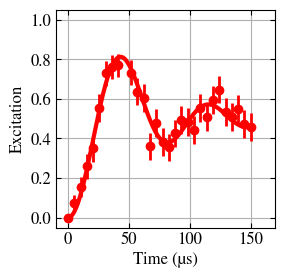

rabi =  0.04934697555525645 ± 0.0019717074770696525 
nbar =  22.999999999790955 ± 6.945419335834863 
nalpha =  45.420919288688886 ± 8.339592059331556 
A =  1.006113729012756 ± 0.02226340551427102


In [28]:
data_path = "/Users/bingran_you/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30424
(
    rabi,
    nbar,
    nalpha,
    amplitude, 
    rabi_err,
    nbar_err,
    nalpha_err,
    amplitude_err,
) = heating_rate_processing(data_path, date, index, number)
print("rabi = ", rabi, "±", rabi_err, "\nnbar = ", nbar, "±", nbar_err, "\nnalpha = ", nalpha, "±", nalpha_err, "\nA = ", amplitude, "±", amplitude_err)

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.10037349510132594 ± 0.0011081425025364733
nbar =  8.685475747700753 ± 2.0285132708332885
nalpha =  14.806211993951845 ± 2.6653000120827772
A =  0.8361433472562239 ± 0.010130091845097992


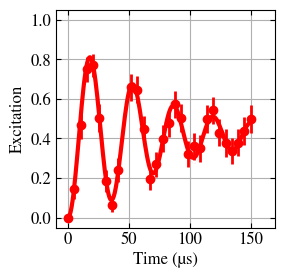

rabi =  0.10037349510132594 ± 0.0011081425025364733 
nbar =  8.685475747700753 ± 2.0285132708332885 
nalpha =  14.806211993951845 ± 2.6653000120827772 
A =  0.8361433472562239 ± 0.010130091845097992


In [29]:
data_path = "/Users/bingran_you/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30462
(
    rabi,
    nbar,
    nalpha,
    amplitude,
    rabi_err,
    nbar_err,
    nalpha_err,
    amplitude_err,
) = heating_rate_processing(data_path, date, index, number, bounds = ((0.05, 0, 0, 0.5), (0.15, 10, 300, 1.5)))
print("rabi = ", rabi, "±", rabi_err, "\nnbar = ", nbar, "±", nbar_err, "\nnalpha = ", nalpha, "±", nalpha_err, "\nA = ", amplitude, "±", amplitude_err)

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.07810797337128764 ± 0.13352888297850263
nbar =  10.293300721936946 ± 8693.196642044313
nalpha =  281.58589623054934 ± 174746.24262873235
A =  1.4565437443070863 ± 1.7154611356819403


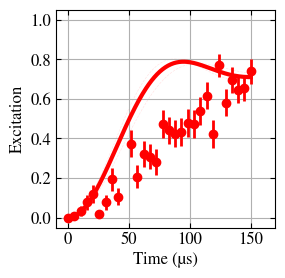

In [31]:
# 8.25
data_path = "/Users/bingran_you/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "18"
number = 30382
(
    rabi,
    nbar,
    nalpha,
    amplitude,
    rabi_err,
    nbar_err,
    nalpha_err,
    amplitude_err,
) = heating_rate_processing(data_path, date, index, number)

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.12745521389180015 ± 4.884496147097319
nbar =  1.0311590429134302e-08 ± 37.089483996186935
nalpha =  200.7324234189531 ± 1588.1957675232811
A =  0.929455367325789 ± 0.27542888469300875


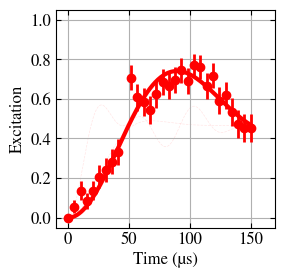

In [32]:
# 6.666
data_path = "/Users/bingran_you/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "18"
number = 30390
(
    rabi,
    nbar,
    nalpha,
    amplitude,
    rabi_err,
    nbar_err,
    nalpha_err,
    amplitude_err,
) = heating_rate_processing(data_path, date, index, number)

In [ ]:
data_path = "/Users/bingran_you/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"

date = "2024-10-27/"

list_frequency = [
    8.25, 6.666, 6.566,
    6.493, 6.493, 6.451, 6.421, 6.42, 6.417, 6.416, 6.415, 6.414, 6.413, 6.41,
    6.4, 6.39, 6.38, 6.35, 6.2, 6.1, 6.05, 6.02, 6.01, 6.005,
    6, 6, 6, 6,
    5.99, 5.98, 5.98, 5.9, 5.882, 5.7, 5.556, 5.5, 5.3, 5.263, 5.2, 5.15, 5.1,
    5, 5, 5,
    4.8, 4.763, 4.762, 4.762,
    4.761, 4.761, 4.761, 4.76, 4.759, 4.5454, 4.5, 4.3478, 4, 3.846, 1.1, 0.55, 0.55
]

indexes = [
    "18", "18", "18", "19", "19", "19", "19", "19", "19", "19", "19", "19", "19", "19", "19",
    "19", "20", "20", "20", "20", "20", "20", "20", "20", "18", "20", "20", "20", "20", "20",
    "20", "20", "19", "20", "19", "20", "20", "19", "20", "20", "20", "19", "19", "20", "20",
    "19", "19", "19", "19", "19", "19", "19", "19", "19", "20", "19", "19", "19", "18", "18",
    "18"
]

numbers = [
    30382, 30390, 30394, 30416, 30418, 30468, 30506, 30478, 30504, 30494, 30498, 30496, 30500, 30472, 30514,
    30474, 30516, 30518, 30522, 30530, 30532, 30534, 30542, 30544, 30386, 30524, 30526, 30546, 30540, 30536,
    30538, 30528, 30398, 30550, 30402, 30552, 30558, 30404, 30572, 30568, 30562, 30408, 30422, 30564, 30574,
    30424, 30412, 30414, 30426, 30428, 30432, 30438, 30444, 30448, 30576, 30456, 30464, 30466, 30350, 30364,
    30368
]

len(list_frequency), len(indexes), len(numbers)

(61, 61, 61)

Processing frequency: 8.25 kHz, index: 18, number: 30382
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.07810797337128764 ± 0.13352888297850263
nbar =  10.293300721936946 ± 8693.196642044313
nalpha =  281.58589623054934 ± 174746.24262873235
A =  1.4565437443070863 ± 1.7154611356819403


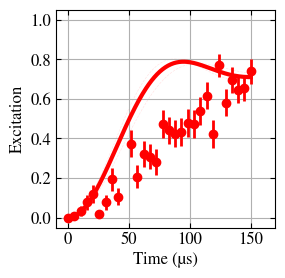

Processing frequency: 6.666 kHz, index: 18, number: 30390
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.12745521389180015 ± 4.884496147097319
nbar =  1.0311590429134302e-08 ± 37.089483996186935
nalpha =  200.7324234189531 ± 1588.1957675232811
A =  0.929455367325789 ± 0.27542888469300875


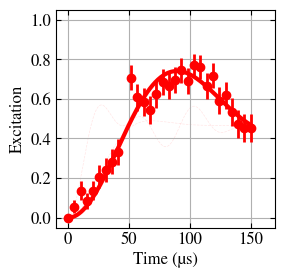

Processing frequency: 6.566 kHz, index: 18, number: 30394
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999996929398512 ± 9.04649828679458
nbar =  0.4112902818572659 ± 105.3397065828968
nalpha =  214.29160081791673 ± 1814.2547680040147
A =  1.167635165331001 ± 0.17998001241545278


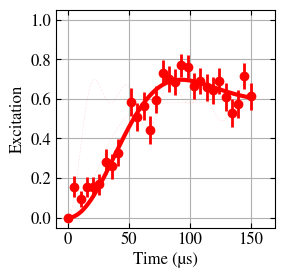

Processing frequency: 6.493 kHz, index: 19, number: 30416
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.07816709288022784 ± 0.6813455268081393
nbar =  22.946221301950864 ± 636.1936464164286
nalpha =  200.2473666184795 ± 175.96429534801004
A =  0.5870800626342468 ± 1.6421819270651776


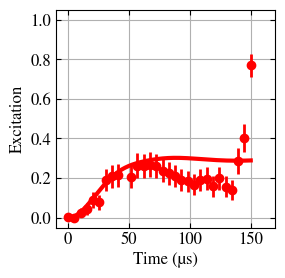

Processing frequency: 6.493 kHz, index: 19, number: 30418
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.1499999999754266 ± 1.18838460551452
nbar =  0.5131159738167579 ± 15.235823657942028
nalpha =  185.14538866024353 ± 433.26506420040124
A =  0.902539592356737 ± 0.023425150002089085


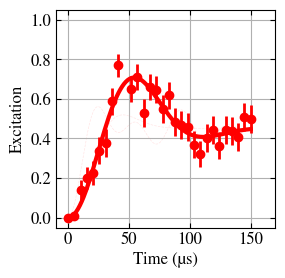

Processing frequency: 6.451 kHz, index: 19, number: 30468
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.13903701962602003 ± 0.013058687690316999
nbar =  22.999999999999996 ± 34.69220726295553
nalpha =  33.73375833557035 ± 30.89710704987403
A =  0.5000000000000001 ± 0.04542828108512013


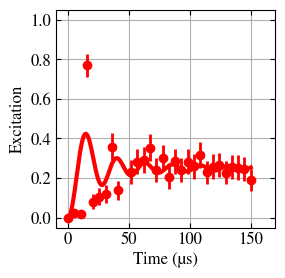

Processing frequency: 6.421 kHz, index: 19, number: 30506
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.149999994226586 ± 4.566606006121037
nbar =  0.7821707385466473 ± 74.08393507609681
nalpha =  195.53577775161128 ± 1413.1904054126292
A =  0.7043664571749771 ± 0.04918078349690765


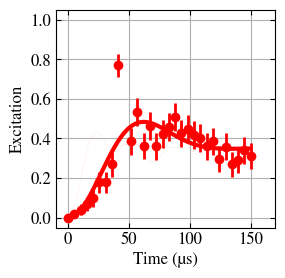

Processing frequency: 6.42 kHz, index: 19, number: 30478
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.02946813454890042 ± 0.03674993398154751
nbar =  22.999999998590045 ± 162.45536911851494
nalpha =  84.05859629327496 ± 149.94907503822782
A =  0.7579875947024746 ± 0.6791638437479154


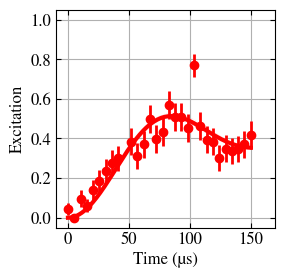

Processing frequency: 6.417 kHz, index: 19, number: 30504
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999999955152 ± 1.9072495715626732
nbar =  0.4010871626651522 ± 21.78834864521647
nalpha =  198.09122910733922 ± 559.8409941946285
A =  1.0675297170660971 ± 0.032318568076883346


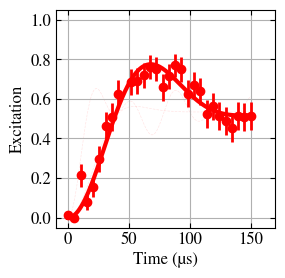

Processing frequency: 6.416 kHz, index: 19, number: 30494
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.1472997171180467 ± 2.017089701714784
nbar =  3.466093709047236e-09 ± 13.053224234878344
nalpha =  195.02937870168935 ± 633.6829868914608
A =  0.9017795910234229 ± 0.04977822798495816


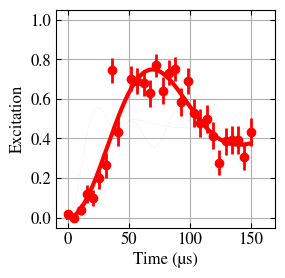

Processing frequency: 6.415 kHz, index: 19, number: 30498
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.024447162311226327 ± 0.06784311531657096
nbar =  22.999999999206217 ± 669.2280040065153
nalpha =  46.79215727156546 ± 655.6420348154744
A =  0.5000000000000001 ± 1.1538953884212206


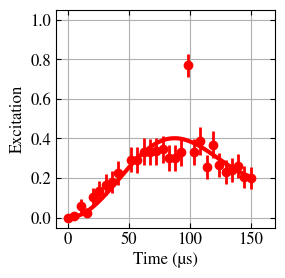

Processing frequency: 6.414 kHz, index: 19, number: 30496
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999958363472 ± 2.626549611590769
nbar =  0.251180844968256 ± 25.08357645584013
nalpha =  200.252227028215 ± 737.1154715664272
A =  0.9446537025087836 ± 0.051187811423249484


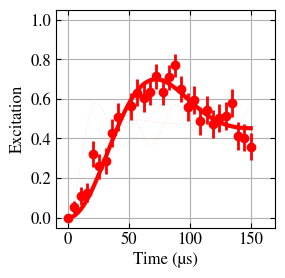

Processing frequency: 6.413 kHz, index: 19, number: 30500
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14218745866923255 ± 3.3624676261836157
nbar =  1.297304454673814e-13 ± 22.511482607047032
nalpha =  192.19730214625747 ± 1149.7838821331457
A =  0.5000000000000001 ± 0.044430150331103896


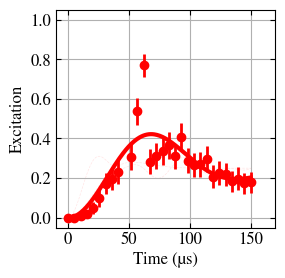

Processing frequency: 6.41 kHz, index: 19, number: 30472
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999992666316 ± 2.2803327880021746
nbar =  0.5088144001749163 ± 29.154029921971137
nalpha =  198.9614233697037 ± 659.4573186368636
A =  1.129744250951264 ± 0.03684155992031707


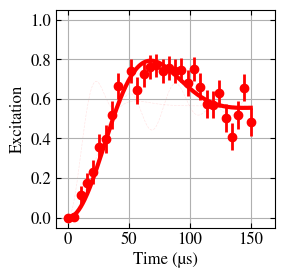

Processing frequency: 6.4 kHz, index: 19, number: 30514
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.11046361575055581 ± 0.29716784709669325
nbar =  2.587129112655598 ± 22.347557993585916
nalpha =  86.19494518486586 ± 335.09722501972635
A =  0.5033805540574356 ± 0.05248140756146083


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/qutip/states.py:416: RuntimeWarning: invalid value encountered in log
  beta = np.log(1.0 / n + 1.0)


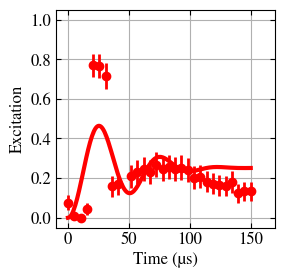

Processing frequency: 6.39 kHz, index: 19, number: 30474
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.03422372006364837 ± 0.05369953141390729
nbar =  22.999999999282036 ± 142.12681878795988
nalpha =  116.32823174067242 ± 132.8587328588306
A =  1.127597927317207 ± 0.9648464940692832


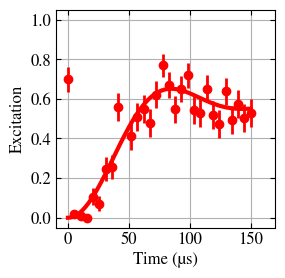

Processing frequency: 6.38 kHz, index: 20, number: 30516
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999990937463 ± 5.06792922337865
nbar =  0.7334366552021186 ± 79.13146908738052
nalpha =  212.61003978961034 ± 1078.5320286054084
A =  1.1587735029059223 ± 0.07023017666670706


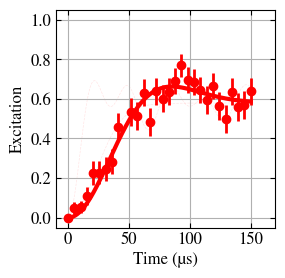

Processing frequency: 6.35 kHz, index: 20, number: 30518
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999999893895 ± 1.3141193112613934
nbar =  0.16902370620076076 ± 11.133741930640516
nalpha =  193.26207880007158 ± 419.3196782943138
A =  0.8745131965219001 ± 0.024532868546184503


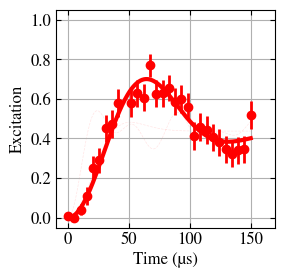

Processing frequency: 6.2 kHz, index: 20, number: 30522
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999999998306 ± 1.1338397935054305
nbar =  0.013818139971898877 ± 7.386686503625731
nalpha =  193.86020664113673 ± 357.15955711706897
A =  0.8677364782466861 ± 0.025230712317926233


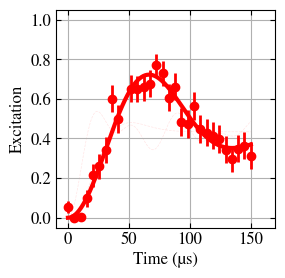

Processing frequency: 6.1 kHz, index: 20, number: 30530
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999999981678 ± 2.1933416608789194
nbar =  0.02536268928583245 ± 14.739221849285105
nalpha =  201.14712031963944 ± 601.6210250445716
A =  0.9288716212857576 ± 0.07271894842718828


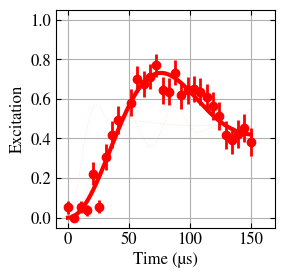

Processing frequency: 6.05 kHz, index: 20, number: 30532
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999999838293 ± 1.2408964195066905
nbar =  0.23891255266059727 ± 11.616392263098804
nalpha =  194.48764585107918 ± 388.03631708424734
A =  0.9909486803535345 ± 0.024052291124124967


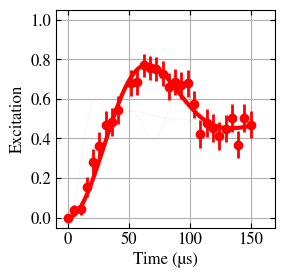

Processing frequency: 6.02 kHz, index: 20, number: 30534
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999999689034 ± 0.24027985089976417
nbar =  4.288914400194667 ± 13.443245292818174
nalpha =  187.85689346484259 ± 89.34438764982613
A =  0.782855839029037 ± 0.041345252345148534


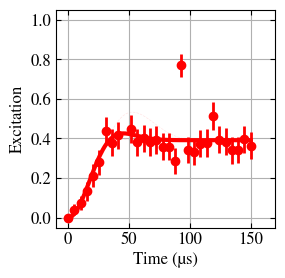

Processing frequency: 6.01 kHz, index: 20, number: 30542
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.0688793483052218 ± 0.02534249869086887
nbar =  6.655065138681281 ± 7.589972471113481
nalpha =  81.33247724126869 ± 47.944644158961935
A =  0.9059845557405206 ± 0.025364125562352506


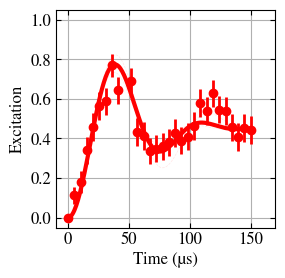

Processing frequency: 6.005 kHz, index: 20, number: 30544
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.046381805717454705 ± 0.002654745620763034
nbar =  22.999999999999996 ± 9.771402962696815
nalpha =  44.95105982249805 ± 12.147411955087737
A =  1.0304345866688944 ± 0.030536382722831896


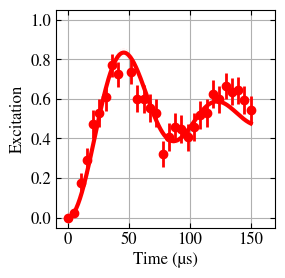

Processing frequency: 6 kHz, index: 18, number: 30386
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999991808932 ± 3.9671633945799165
nbar =  1.5202329109928987 ± 100.22669215225233
nalpha =  199.66716121959172 ± 1153.4046432618038
A =  0.5990999092873074 ± 0.0785283305356995


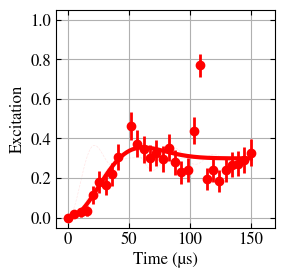

Processing frequency: 6 kHz, index: 20, number: 30524
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.05609629368411173 ± 0.004979262511685232
nbar =  12.535518856290624 ± 5.5588858302778705
nalpha =  52.92266545024485 ± 14.168247957671461
A =  0.954209869066867 ± 0.022160513709161982


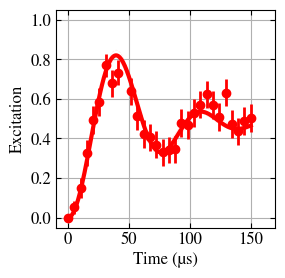

Processing frequency: 6 kHz, index: 20, number: 30526
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.149999999994536 ± 1.9301351257392891
nbar =  0.7984880001532438 ± 32.683493827117324
nalpha =  155.45171953033557 ± 996.69139439462
A =  0.5390950218524417 ± 0.04807645326974896


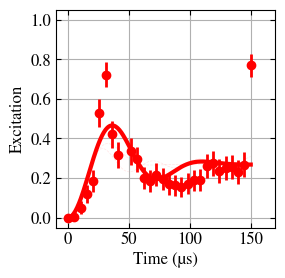

Processing frequency: 6 kHz, index: 20, number: 30546
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.149999999994594 ± 0.804644982751504
nbar =  1.4911510822683829 ± 20.459486860765004
nalpha =  172.57851055503238 ± 349.2264021953247
A =  0.9487914793276441 ± 0.024432234339109928


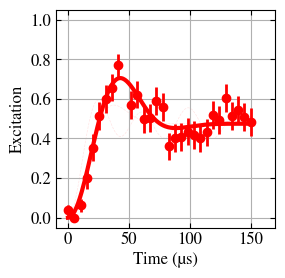

Processing frequency: 5.99 kHz, index: 20, number: 30540
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.06937276945819591 ± 0.016413117002342548
nbar =  8.886641147223301 ± 6.589987443977461
nalpha =  80.5274459513275 ± 31.337214331609392
A =  0.9664537709421949 ± 0.021118039646920193


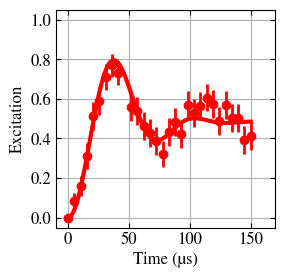

Processing frequency: 5.98 kHz, index: 20, number: 30536
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.03373127818851461 ± 0.009179138842482521
nbar =  22.999999999999666 ± 67.85356242466685
nalpha =  28.14945750799304 ± 81.30007111935485
A =  0.522245976689034 ± 0.05784506389402025


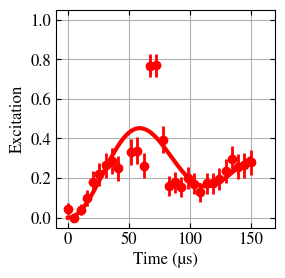

Processing frequency: 5.98 kHz, index: 20, number: 30538
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.04170245104167979 ± 0.001979091976646636
nbar =  22.609434609575292 ± 8.321396901635454
nalpha =  42.220512963138916 ± 10.314507048278665
A =  0.9424979181486056 ± 0.023257353262243


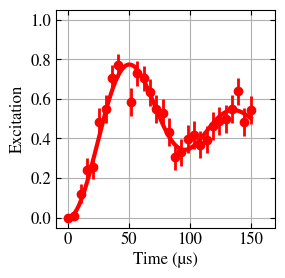

Processing frequency: 5.9 kHz, index: 20, number: 30528
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14948576411659847 ± 0.012966418352825151
nbar =  12.067556684853004 ± 5546.108319130578
nalpha =  278.5892442897424 ± 94661.2199480138
A =  1.190125748428401 ± 0.05348537851362245


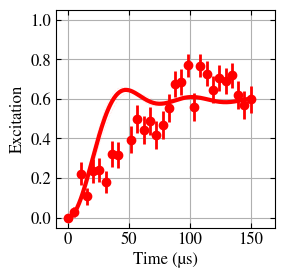

Processing frequency: 5.882 kHz, index: 19, number: 30398
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.13208401474018674 ± 0.07172143135977822
nbar =  6.208282556996405 ± 46083.67334766943
nalpha =  288.8740695272039 ± 1578266.0195300316
A =  0.5679762641212573 ± 0.4183916870952555


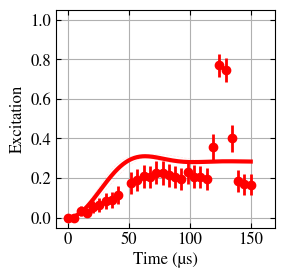

Processing frequency: 5.7 kHz, index: 20, number: 30550
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.055305068583026126 ± 0.05083369138228071
nbar =  5.8415185509203225 ± 13.13691357182284
nalpha =  123.25832882842471 ± 94.13157019175416
A =  0.9260699069211277 ± 0.032321392843002325


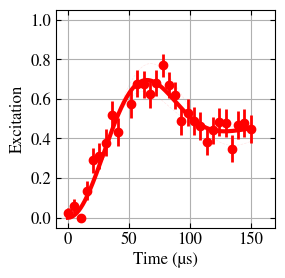

Processing frequency: 5.556 kHz, index: 19, number: 30402
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999972754285 ± 15.253549878911588
nbar =  0.44221420417015306 ± 183.52709334119928
nalpha =  214.9509085248041 ± 3003.302744366206
A =  1.1393342218381148 ± 0.26398066910998413


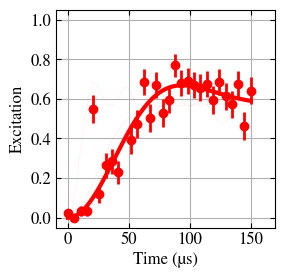

Processing frequency: 5.5 kHz, index: 20, number: 30552
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999966710573 ± 8.885997975105536
nbar =  0.18525687552852782 ± 77.91981854726106
nalpha =  206.5488975920686 ± 2170.7591238010614
A =  0.6583710539329817 ± 0.18253216763796143


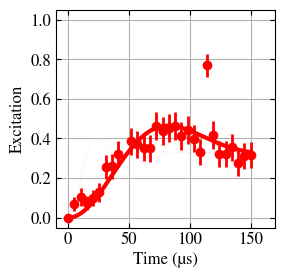

Processing frequency: 5.3 kHz, index: 20, number: 30558
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999999940916 ± 0.6979918051610645
nbar =  2.5066177171330892 ± 25.688115511564664
nalpha =  193.05650183895202 ± 232.374097751681
A =  0.8436401866827657 ± 0.04727746102444118


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/qutip/states.py:416: RuntimeWarning: invalid value encountered in log
  beta = np.log(1.0 / n + 1.0)


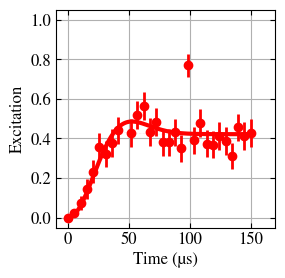

Processing frequency: 5.263 kHz, index: 19, number: 30404
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.09039857525789838 ± 0.4014759869377782
nbar =  18.60057474748088 ± 270.9400129369936
nalpha =  225.5658887157739 ± 363.06530899581026
A =  0.5933822737141875 ± 1.0181476548632638


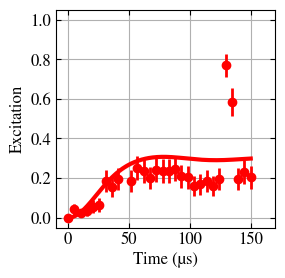

Processing frequency: 5.2 kHz, index: 20, number: 30572
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.023838198662087265 ± 0.11882793667214615
nbar =  22.999999999999012 ± 1283.343679897525
nalpha =  44.376284050900004 ± 1250.5122012586498
A =  0.5000000000001104 ± 2.1272319060591425


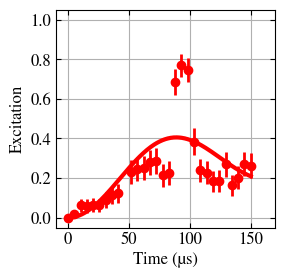

Processing frequency: 5.15 kHz, index: 20, number: 30568
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.1135389159726704 ± 0.28277799517984964
nbar =  3.6940511239273426 ± 20.085693194811235
nalpha =  174.86382760471616 ± 160.10515001481428
A =  1.2504285631022427 ± 0.04677508132421297


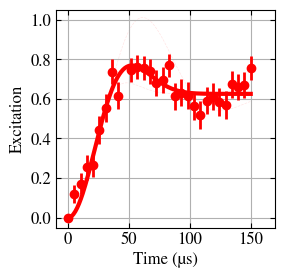

Processing frequency: 5.1 kHz, index: 20, number: 30562
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.1004355956239492 ± 0.28954093985885443
nbar =  22.998199798954555 ± 198.55263871926314
nalpha =  198.87628823340864 ± 70.47551229247335
A =  0.6056585122850625 ± 0.4900242755871969


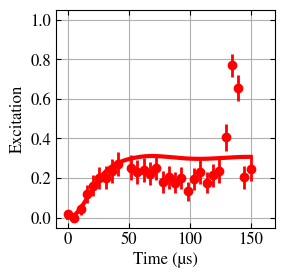

Processing frequency: 5 kHz, index: 19, number: 30408
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999849870926 ± 6.861385193727186
nbar =  0.7387935552025591 ± 107.31378709017504
nalpha =  216.1156648980022 ± 1325.2835798420128
A =  1.2439008301926893 ± 0.15757970092561702


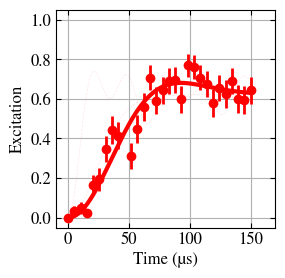

Processing frequency: 5 kHz, index: 19, number: 30422
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999993750363 ± 0.2844286621631927
nbar =  1.9430777180524024 ± 8.109258839441324
nalpha =  208.18389405221404 ± 72.7475703703072
A =  1.2472736840396905 ± 0.04391912609414163


/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/qutip/states.py:417: RuntimeWarning: overflow encountered in exp
  diags = np.exp(-beta * i)
/opt/anaconda3/envs/multiplexing/lib/python3.9/site-packages/qutip/states.py:418: RuntimeWarning: invalid value encountered in divide
  diags = diags / np.sum(diags)


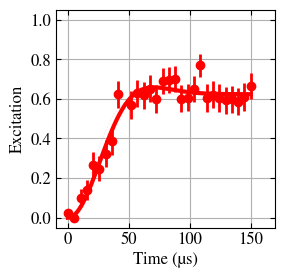

Processing frequency: 5 kHz, index: 20, number: 30564
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999999999997 ± 0.08244419420395938
nbar =  3.3050790666210434 ± 3.0915647788623075
nalpha =  212.65885620077262 ± 24.277008399104925
A =  1.1867473201425809 ± 0.041289066174595275


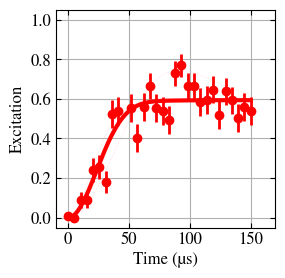

Processing frequency: 4.8 kHz, index: 20, number: 30574
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.1499999998960115 ± 1.8106834831646252
nbar =  0.36049166202580635 ± 19.721723707906015
nalpha =  193.41364979028953 ± 577.990413730028
A =  0.9347459911318401 ± 0.03008757312829664


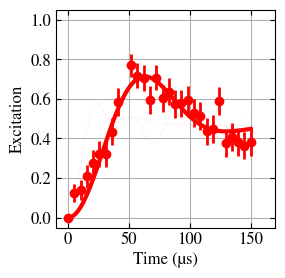

Processing frequency: 4.763 kHz, index: 19, number: 30424
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.04934697555525645 ± 0.0019717074770696525
nbar =  22.999999999790955 ± 6.945419335834863
nalpha =  45.420919288688886 ± 8.339592059331556
A =  1.006113729012756 ± 0.02226340551427102


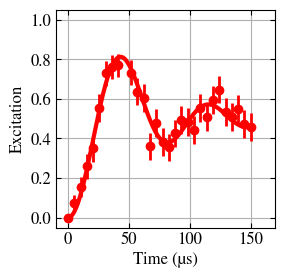

Processing frequency: 4.762 kHz, index: 19, number: 30412
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.08014981616307651 ± 0.15568330375334738
nbar =  22.970669346662152 ± 118.83878810830582
nalpha =  134.24366393701607 ± 188.24989040532785
A =  0.6776602772531639 ± 0.22312701827857925


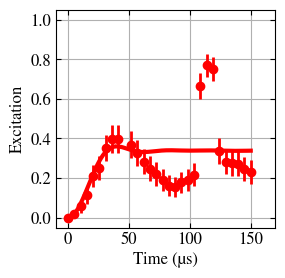

Processing frequency: 4.762 kHz, index: 19, number: 30414
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.044318708346323996 ± 0.002245613958581905
nbar =  22.999999999999996 ± 15.64127184385185
nalpha =  25.92863750048396 ± 16.550583379415528
A =  0.9333156907492857 ± 0.03195841303856227


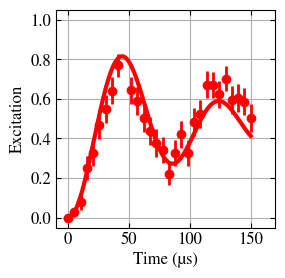

Processing frequency: 4.761 kHz, index: 19, number: 30426
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.07434429189933654 ± 0.02774520715241094
nbar =  4.374955624128204 ± 4.522723184497856
nalpha =  97.58090149053932 ± 44.24016092048405
A =  0.8231532099774947 ± 0.01333177218103795


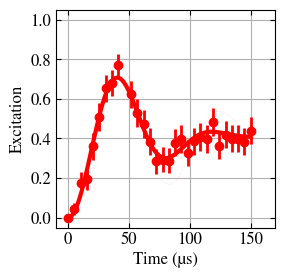

Processing frequency: 4.761 kHz, index: 19, number: 30428
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.04234144381956894 ± 0.002694130257372193
nbar =  22.999999999954376 ± 39.61518410519926
nalpha =  13.280270708153308 ± 39.743870857016766
A =  0.6437067906719555 ± 0.03356032203974215


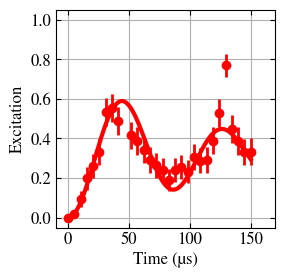

Processing frequency: 4.761 kHz, index: 19, number: 30432
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.04617740063884533 ± 0.003024218080028009
nbar =  22.999999999999996 ± 11.295775256002745
nalpha =  44.528310818993205 ± 13.999563176131513
A =  1.0496921525276268 ± 0.03573398279098263


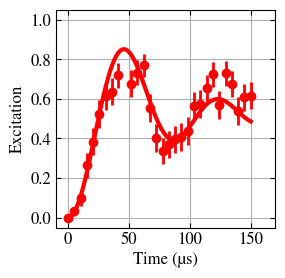

Processing frequency: 4.76 kHz, index: 19, number: 30438
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.05056933744248771 ± 0.004454754107660929
nbar =  16.06047958584035 ± 6.703625662098839
nalpha =  58.33065324507537 ± 14.166462360135673
A =  0.9065477526650277 ± 0.022338552845436933


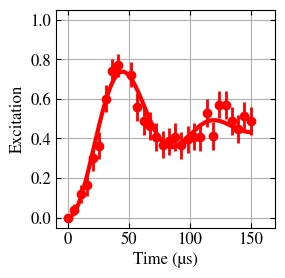

Processing frequency: 4.759 kHz, index: 19, number: 30444
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.05503100448981365 ± 0.006670704173454454
nbar =  22.999999999999996 ± 9.985822832909891
nalpha =  92.3050347757307 ± 16.69765396775021
A =  1.0981940949372955 ± 0.04138534447399876


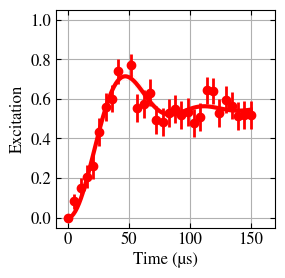

Processing frequency: 4.5454 kHz, index: 19, number: 30448
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999344108864 ± 7.086069680073026
nbar =  0.35279837559410737 ± 77.22319994850474
nalpha =  211.42900830739495 ± 1537.461051034678
A =  1.0893381505491337 ± 0.15562115022324202


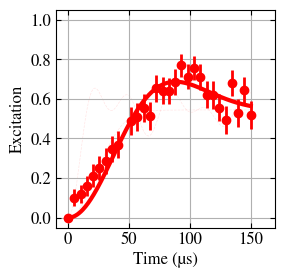

Processing frequency: 4.5 kHz, index: 20, number: 30576
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.02000000000000251 ± 0.3407410645681889
nbar =  19.759120378174792 ± 3121.4738289963757
nalpha =  55.51447471638855 ± 3121.2459381788176
A =  0.5000000000000001 ± 7.305942502347998


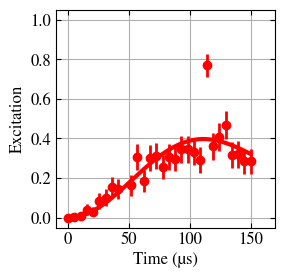

Processing frequency: 4.3478 kHz, index: 19, number: 30456
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999999999997 ± 0.28785825976386414
nbar =  6.844304900808302 ± 26.090185406683776
nalpha =  173.03625935992437 ± 131.3373537582918
A =  0.6216104986242259 ± 0.05674132380971988


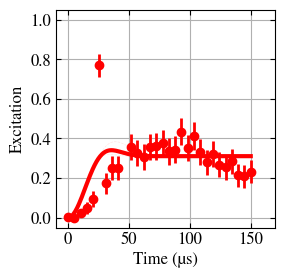

Processing frequency: 4 kHz, index: 19, number: 30464
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.02152149487559523 ± 0.41003128350910006
nbar =  22.999999999999954 ± 3330.348205103032
nalpha =  81.17309805846864 ± 1852.0354748240895
A =  0.5000000000000001 ± 11.66586491003516


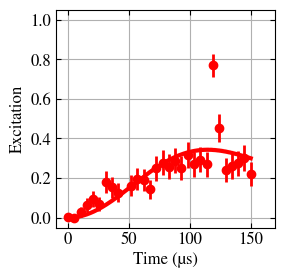

Processing frequency: 3.846 kHz, index: 19, number: 30466
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999997976116 ± 0.9578676765898623
nbar =  0.40763112913118277 ± 11.063775048430687
nalpha =  174.39442187922089 ± 402.63757801748045
A =  0.8127744954495388 ± 0.024315217387997794


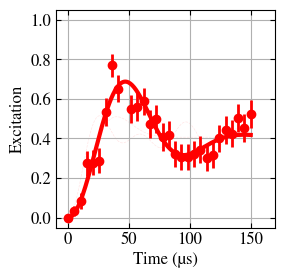

Processing frequency: 1.1 kHz, index: 18, number: 30350
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.090025659664146 ± 0.06901530132445967
nbar =  7.876535524391885 ± 14.159016225280586
nalpha =  126.00549226895805 ± 78.1201891296086
A =  1.0760345305442747 ± 0.03198208507672424


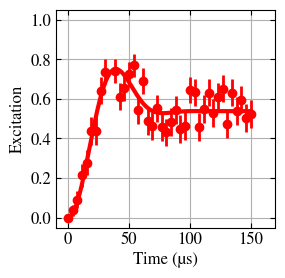

Processing frequency: 0.55 kHz, index: 18, number: 30364
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.11701893734537855 ± 0.0238561835825901
nbar =  22.999999907851155 ± 18.611109234320736
nalpha =  80.98091394094646 ± 34.21810193572531
A =  0.6884264086243993 ± 0.032179057019580425


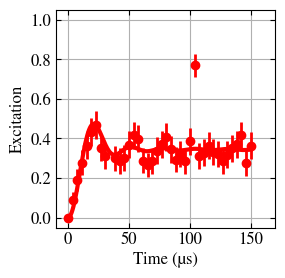

Processing frequency: 0.55 kHz, index: 18, number: 30368
Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.10449658587703038 ± 0.019819002429079694
nbar =  22.99999997457277 ± 16.014313587933774
nalpha =  86.16176055946731 ± 29.349947791207804
A =  0.7892080326116027 ± 0.03283898517466003


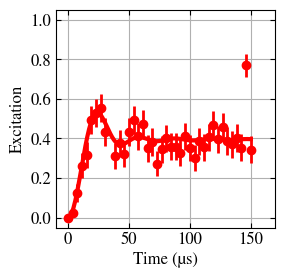

In [34]:
for freq, idx, num in zip(list_frequency, indexes, numbers):
    print(f"Processing frequency: {freq} kHz, index: {idx}, number: {num}")
    (
        rabi,
        nbar,
        nalpha,
        amplitude,
        rabi_err,
        nbar_err,
        nalpha_err,
        amplitude_err,
    ) = heating_rate_processing(data_path, date, idx, num)